# Task 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv('diabetes.csv')

In [3]:
# prints the dimensions as (rows, columns)
print('Shape:', df.shape)

# displays the first 5 rows
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# Zeros here mean missing data
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts in physiologically impossible columns:')
print((df[zero_cols] == 0).sum())

Zero counts in physiologically impossible columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


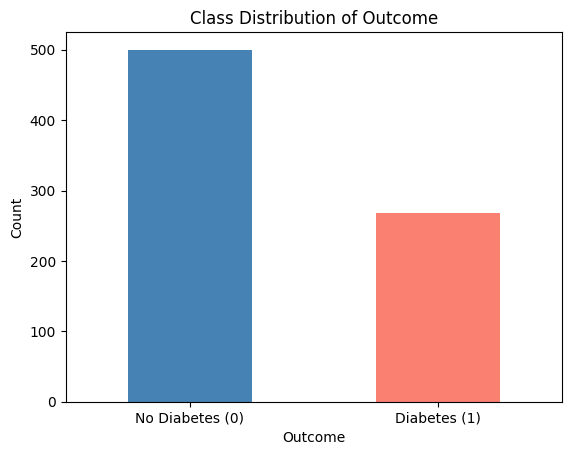

In [6]:
# Class distribuition
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution of Outcome')
plt.show()

**Class Distribution — Observations:**

The dataset contains 500 negative cases (no diabetes) and 268 positive cases (diabetes), giving a roughly 65/35 split. The classes are **moderately imbalanced** — there are nearly twice as many non-diabetic patients as diabetic ones. This means a naive classifier that always predicts "no diabetes" would achieve ~65% accuracy without learning anything useful. As a result, **F1 score** is a more meaningful metric than accuracy alone for this problem, as it accounts for the model's ability to correctly identify the minority (diabetic) class.

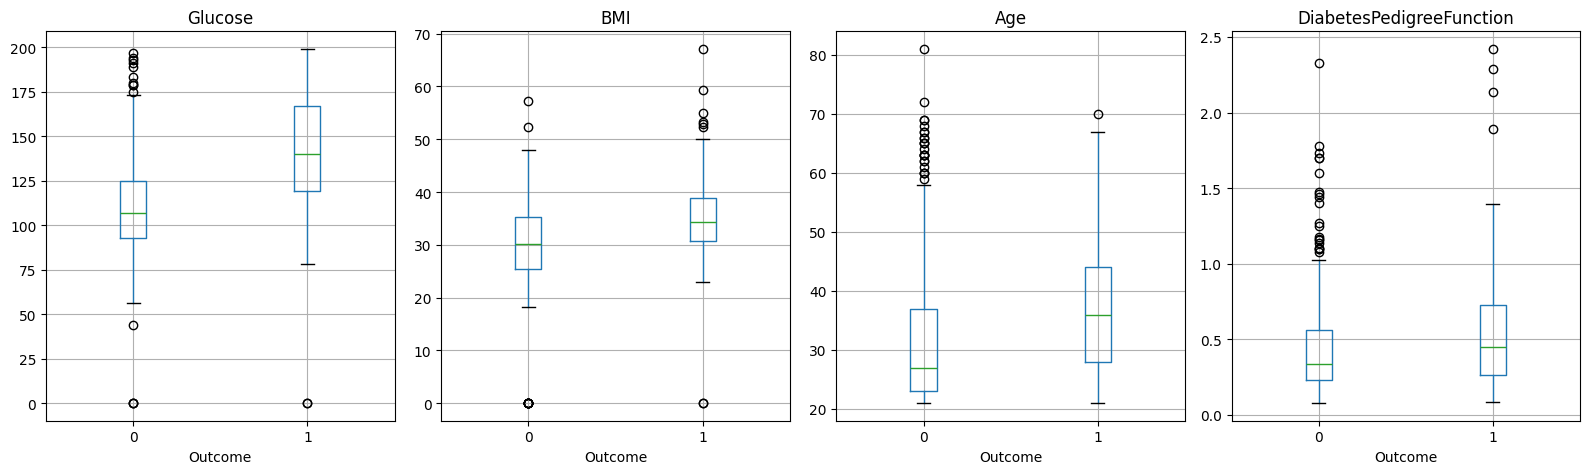

In [7]:
features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feature in zip(axes, features):
    df.boxplot(column=feature, by='Outcome', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Outcome')

plt.suptitle('')
plt.tight_layout()
plt.show()